# **How to Start Project**
* conda deactivate
* conda create -n ml_summer_course python=3.11
* conda activate ml_summer_course
* pip install ipykernel
==========================================
##### Github Push
- git config --global user.name "XYZ"
- git config --global user.email "XYZ@example.com"


## **ML Life Cycle** 
![Room Occupancy Dataset](img2.png)

# **Library**

In [50]:
# ===============================================================
# ===============================================================
# EDA Library 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
import math
# ===============================================================
# ===============================================================
# Data Preprocessing Library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
# ===============================================================
# ===============================================================
# Machine Learning Library
# ===============================================================
# ===============================================================
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
# Machine Learning Models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Model Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)



# **Room Occupancy Estimation Data Set**
##### Kaggle Link : https://www.kaggle.com/datasets/ananthr1/room-occupancy-estimation-data-set?utm_source=chatgpt.com
![Room Occupancy Dataset](img1.png)

# **1 - Data Understanding**

In [2]:
# Read Data 
data = pd.read_csv(r'F:\Programming\ECU\Summer Course 2025\Subjects\ML Course\Dataset\Occupancy_Estimation.csv')
df = data.copy()
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [3]:
# Random Data
df.sample(5)


,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
4772,2017/12/24,04:35:37,25.25,25.25,24.69,25.56,0,0,0,0,0.08,0.05,0.06,0.06,360,0.000000e+00,0,0,0
6466,2017/12/25,19:12:39,25.44,25.44,25.13,26.06,0,0,0,0,0.07,0.06,0.05,0.10,355,-4.615385e-02,0,0,0
1811,2017/12/23,03:01:19,25.25,25.31,24.75,25.63,0,0,0,0,0.06,0.05,0.06,0.06,365,0.000000e+00,0,0,0
3428,2017/12/23,16:59:42,26.13,25.88,25.63,26.31,118,24,192,14,0.27,0.10,0.06,0.08,625,2.142308e+00,0,0,2
5273,2017/12/24,08:55:00,25.13,25.13,24.63,25.44,6,7,35,23,0.08,0.05,0.07,0.06,360,7.698012e-19,0,0,0


In [4]:
# size of the dataset
df.shape    

(10129, 19)

In [5]:
# Data Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  str    
 1   Time                  10129 non-null  str    
 2   S1_Temp               10129 non-null  float64
 3   S2_Temp               10129 non-null  float64
 4   S3_Temp               10129 non-null  float64
 5   S4_Temp               10129 non-null  float64
 6   S1_Light              10129 non-null  int64  
 7   S2_Light              10129 non-null  int64  
 8   S3_Light              10129 non-null  int64  
 9   S4_Light              10129 non-null  int64  
 10  S1_Sound              10129 non-null  float64
 11  S2_Sound              10129 non-null  float64
 12  S3_Sound              10129 non-null  float64
 13  S4_Sound              10129 non-null  float64
 14  S5_CO2                10129 non-null  int64  
 15  S5_CO2_Slope          10129 no

In [6]:
df.columns

Index(['Date', 'Time', 'S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light',
       'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound',
       'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR',
       'Room_Occupancy_Count'],
      dtype='str')

In [7]:
# Check Description of the dataset
df.describe()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
count,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.00000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000
mean,25.454012,25.546059,25.056621,25.754125,25.445059,26.01629,34.248494,13.220259,0.168178,0.120066,0.158119,0.103840,460.860401,-0.004830,0.090137,0.079574,0.398559
std,0.351351,0.586325,0.427283,0.356434,51.011264,67.30417,58.400744,19.602219,0.316709,0.266503,0.413637,0.120683,199.964940,1.164990,0.286392,0.270645,0.893633
min,24.940000,24.750000,24.440000,24.940000,0.000000,0.00000,0.000000,0.000000,0.060000,0.040000,0.040000,0.050000,345.000000,-6.296154,0.000000,0.000000,0.000000
25%,25.190000,25.190000,24.690000,25.440000,0.000000,0.00000,0.000000,0.000000,0.070000,0.050000,0.060000,0.060000,355.000000,-0.046154,0.000000,0.000000,0.000000
50%,25.380000,25.380000,24.940000,25.750000,0.000000,0.00000,0.000000,0.000000,0.080000,0.050000,0.060000,0.080000,360.000000,0.000000,0.000000,0.000000,0.000000
75%,25.630000,25.630000,25.380000,26.000000,12.000000,14.00000,50.000000,22.000000,0.080000,0.060000,0.070000,0.100000,465.000000,0.000000,0.000000,0.000000,0.000000
max,26.380000,29.000000,26.190000,26.560000,165.000000,258.00000,280.000000,74.000000,3.880000,3.440000,3.670000,3.400000,1270.000000,8.980769,1.000000,1.000000,3.000000


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
S1_Temp,10129.0,25.454012,0.351351,24.940000,25.190000,25.38,25.63,26.380000
S2_Temp,10129.0,25.546059,0.586325,24.750000,25.190000,25.38,25.63,29.000000
S3_Temp,10129.0,25.056621,0.427283,24.440000,24.690000,24.94,25.38,26.190000
S4_Temp,10129.0,25.754125,0.356434,24.940000,25.440000,25.75,26.00,26.560000
S1_Light,10129.0,25.445059,51.011264,0.000000,0.000000,0.00,12.00,165.000000
S2_Light,10129.0,26.016290,67.304170,0.000000,0.000000,0.00,14.00,258.000000
S3_Light,10129.0,34.248494,58.400744,0.000000,0.000000,0.00,50.00,280.000000
S4_Light,10129.0,13.220259,19.602219,0.000000,0.000000,0.00,22.00,74.000000
S1_Sound,10129.0,0.168178,0.316709,0.060000,0.070000,0.08,0.08,3.880000
S2_Sound,10129.0,0.120066,0.266503,0.040000,0.050000,0.05,0.06,3.440000


In [9]:
# Number of unique values in each column
df.nunique()

Date                        7
Time                    10129
S1_Temp                    24
S2_Temp                    69
S3_Temp                    29
S4_Temp                    27
S1_Light                   68
S2_Light                   82
S3_Light                  177
S4_Light                   75
S1_Sound                  231
S2_Sound                  185
S3_Sound                  258
S4_Sound                  106
S5_CO2                    186
S5_CO2_Slope             1579
S6_PIR                      2
S7_PIR                      2
Room_Occupancy_Count        4
dtype: int64

In [10]:
# Check Balance of the dataset
df['Room_Occupancy_Count'].value_counts()

Room_Occupancy_Count
0    8228
2     748
3     694
1     459
Name: count, dtype: int64

In [11]:
# Check Balance of the dataset
round(df['Room_Occupancy_Count'].value_counts(normalize=True)*100, 2) 

Room_Occupancy_Count
0    81.23
2     7.38
3     6.85
1     4.53
Name: proportion, dtype: float64

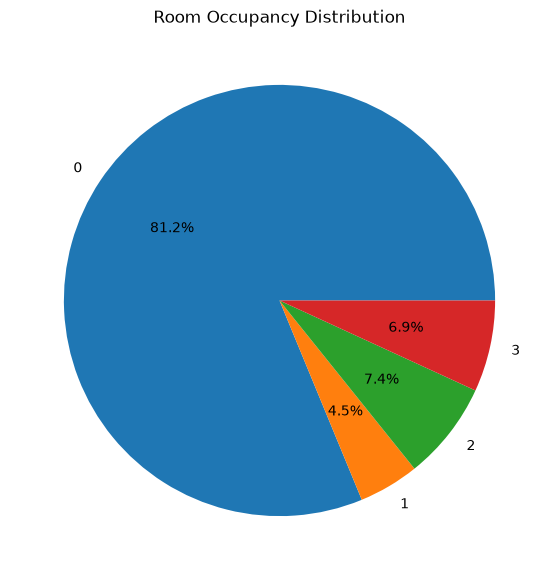

In [12]:
# Vizualization of the dataset
balance = (
    df['Room_Occupancy_Count']
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)
plt.figure(figsize=(7,7))

balance.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Room Occupancy Distribution')
plt.show()

# **2 - Data Cleaning**

In [13]:
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [14]:
# 1. Correct Data Types and Convert Date/Time
# This step is important for feature engineering
df["Timestamp"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    errors="coerce"
)
# error="coerce" will convert invalid parsing to NaT (Not a Time)

df = df.sort_values("Timestamp").reset_index(drop=True)
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,Timestamp
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1,2017-12-22 10:49:41
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1,2017-12-22 10:50:12
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1,2017-12-22 10:50:42
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1,2017-12-22 10:51:13
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1,2017-12-22 10:51:44


#### **2. Check and Handle Missing Values**
##### **Handling Missing Values**

1. **Mean:** Use with numerical data when there are no outliers.
2. **Median:** Use with numerical data when the data contains outliers or is skewed.
3. **Mode:** Use with categorical or binary data, such as `S6_PIR` and `S7_PIR`.
4. **Drop Rows:** Remove rows when the missing value is in the target column or when very few rows are affected.

![Room Occupancy Dataset](img3.png)

In [15]:
df.isnull().sum()

Date                    0
Time                    0
S1_Temp                 0
S2_Temp                 0
S3_Temp                 0
S4_Temp                 0
S1_Light                0
S2_Light                0
S3_Light                0
S4_Light                0
S1_Sound                0
S2_Sound                0
S3_Sound                0
S4_Sound                0
S5_CO2                  0
S5_CO2_Slope            0
S6_PIR                  0
S7_PIR                  0
Room_Occupancy_Count    0
Timestamp               0
dtype: int64

In [16]:
# 3. Detect and Remove Duplicate Rows
print("Duplicated rows:", df.duplicated().sum())
# if data is dublicated, we can remove it using the drop_duplicates() method.
#  df = df.drop_duplicates()

Duplicated rows: 0


In [ ]:
# 4. Check Invalid or Impossible Values 
print(df["S6_PIR"].unique())
print(df["S7_PIR"].unique())
print(df["Room_Occupancy_Count"].unique())

[0 1]
[0 1]
[1 2 3 0]


In [18]:
# ~ mean not  [ Select values that are NOT 0 or 1 by inverting the Boolean mask ]
invalid_pir = df[
    ~df["S6_PIR"].isin([0, 1]) |
    ~df["S7_PIR"].isin([0, 1])
]

invalid_target = df[
    ~df["Room_Occupancy_Count"].isin([0, 1, 2, 3])
]

print("Invalid PIR rows:", len(invalid_pir))
print("Invalid target rows:", len(invalid_target))

Invalid PIR rows: 0
Invalid target rows: 0


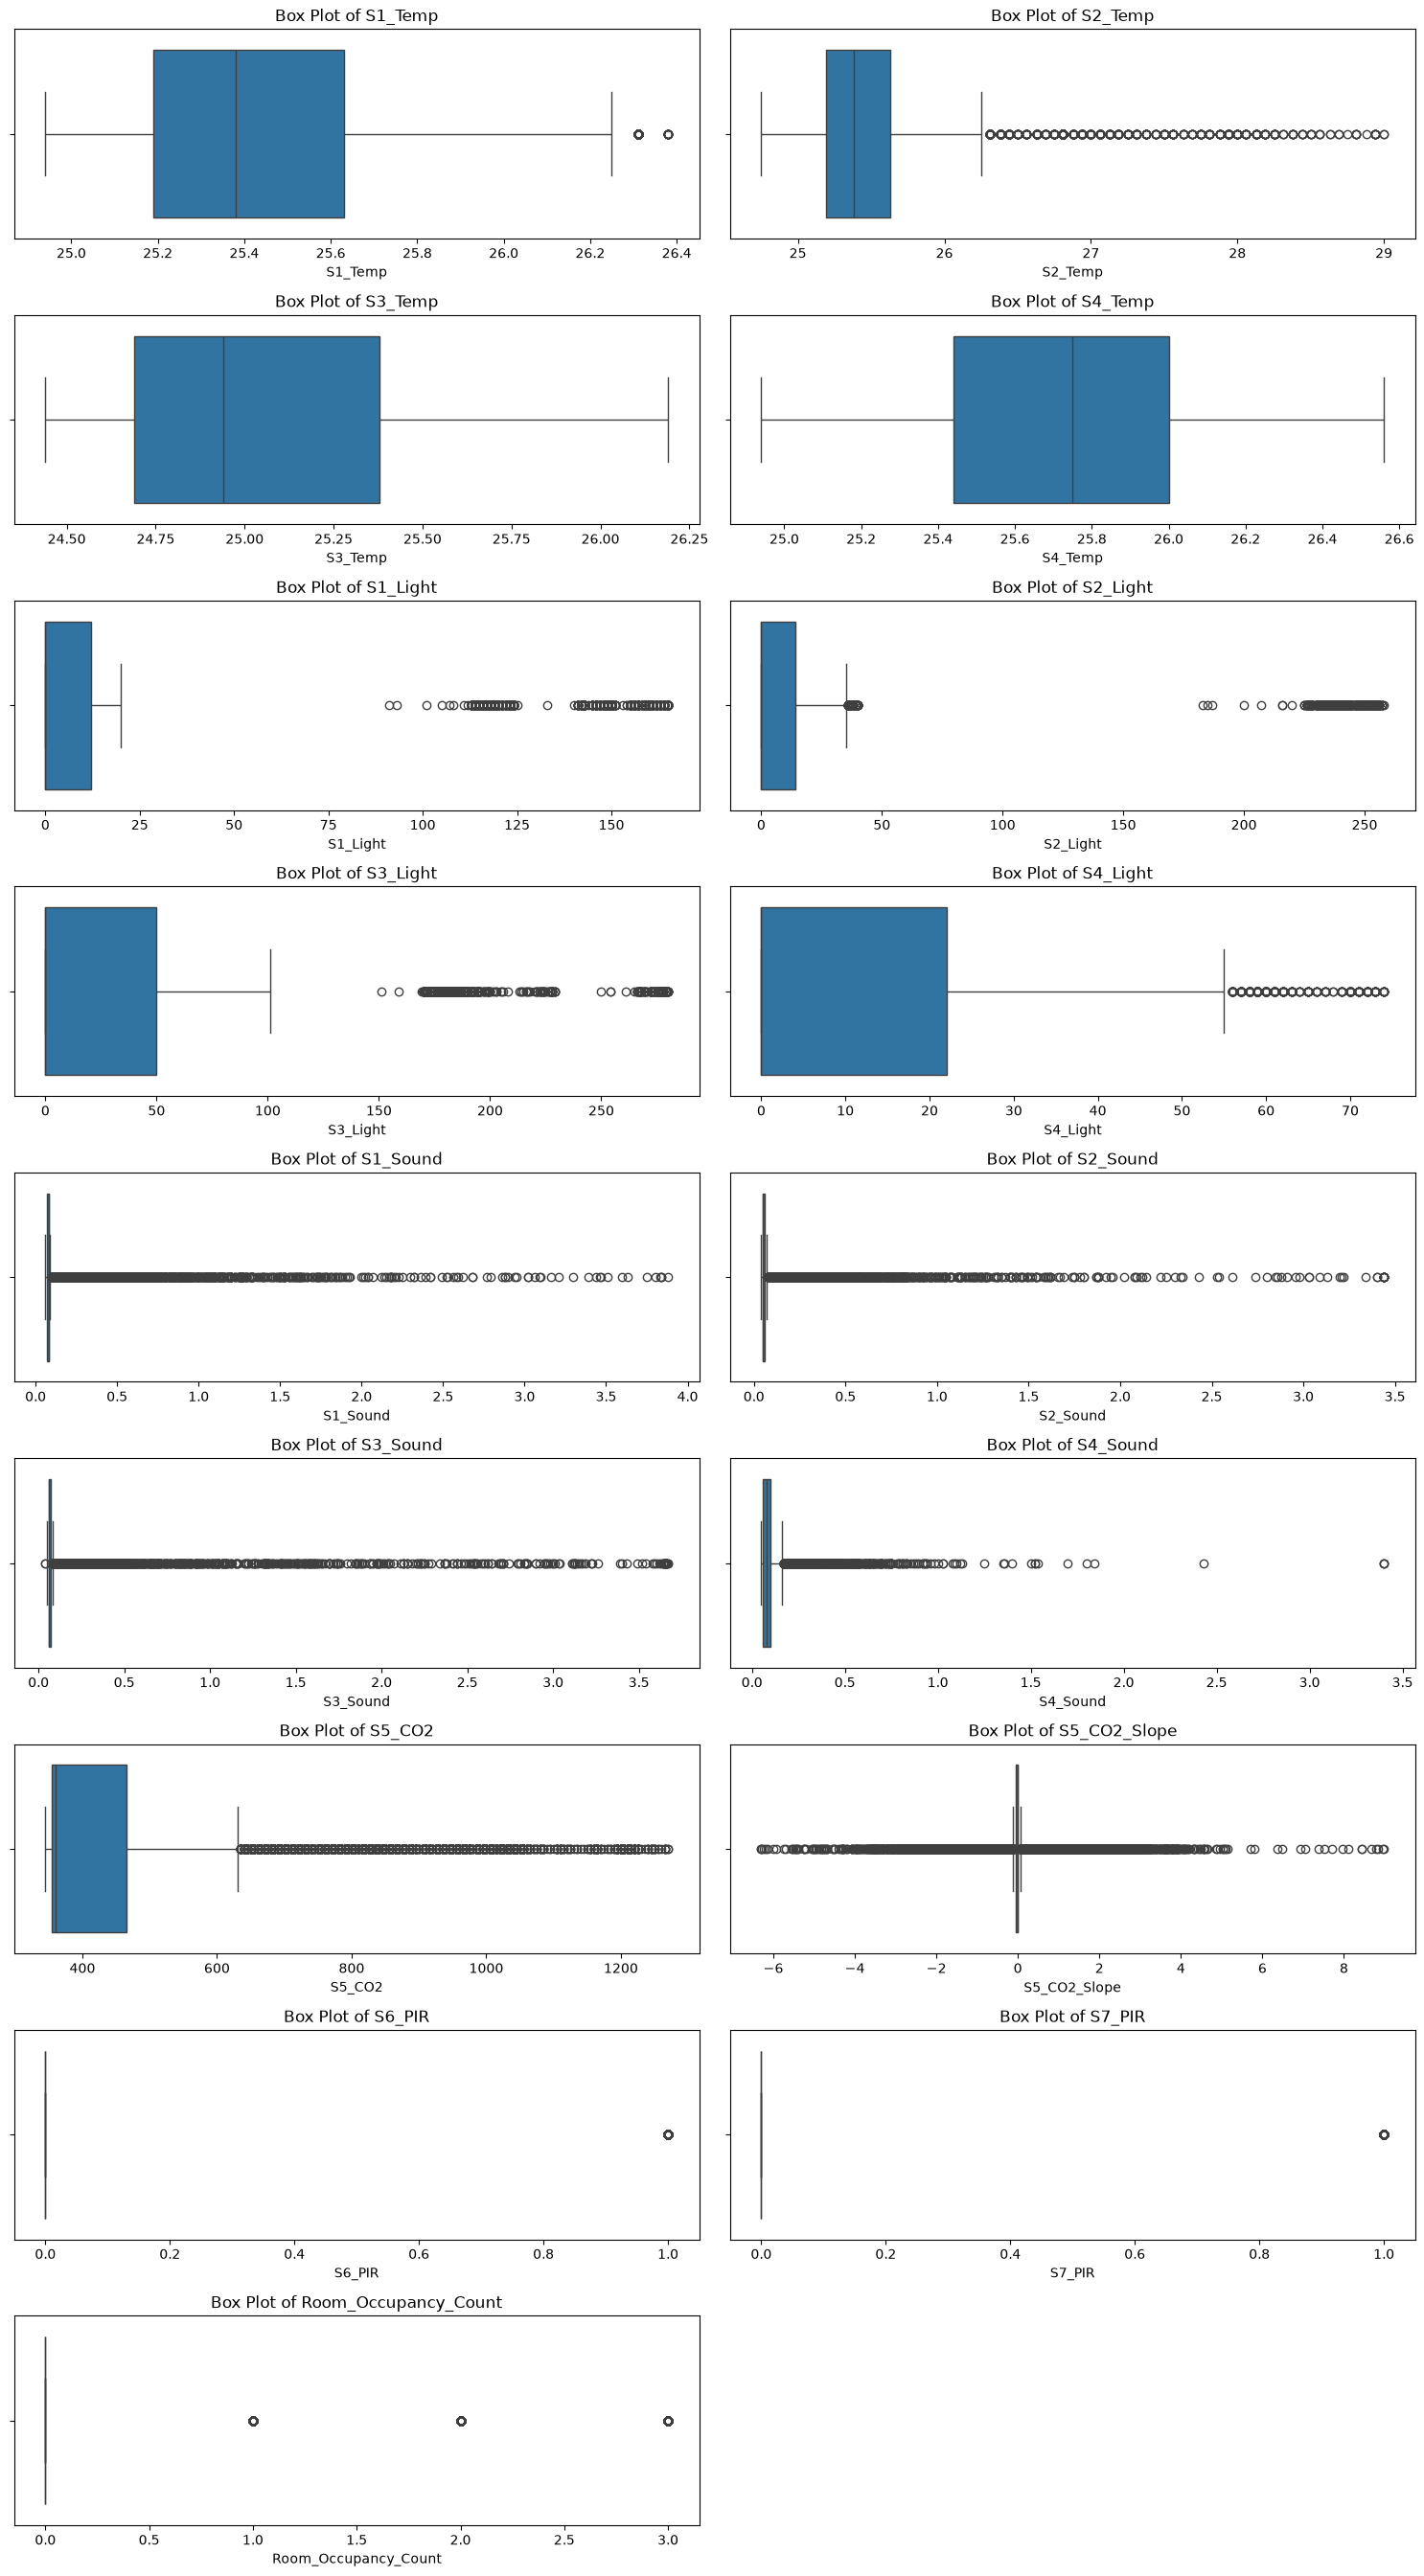

In [19]:
# 5 - Check Outliers
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

cols = 2
rows = math.ceil(len(num_cols) / cols) # (19 /2) = 9.5 => 10

plt.figure(figsize=(15, rows * 3))

for i, feature in enumerate(num_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=df[feature])
    plt.title(f"Box Plot of {feature}")

plt.tight_layout()
plt.show()

# **3) - Exploratory Data Analysis (EDA)**

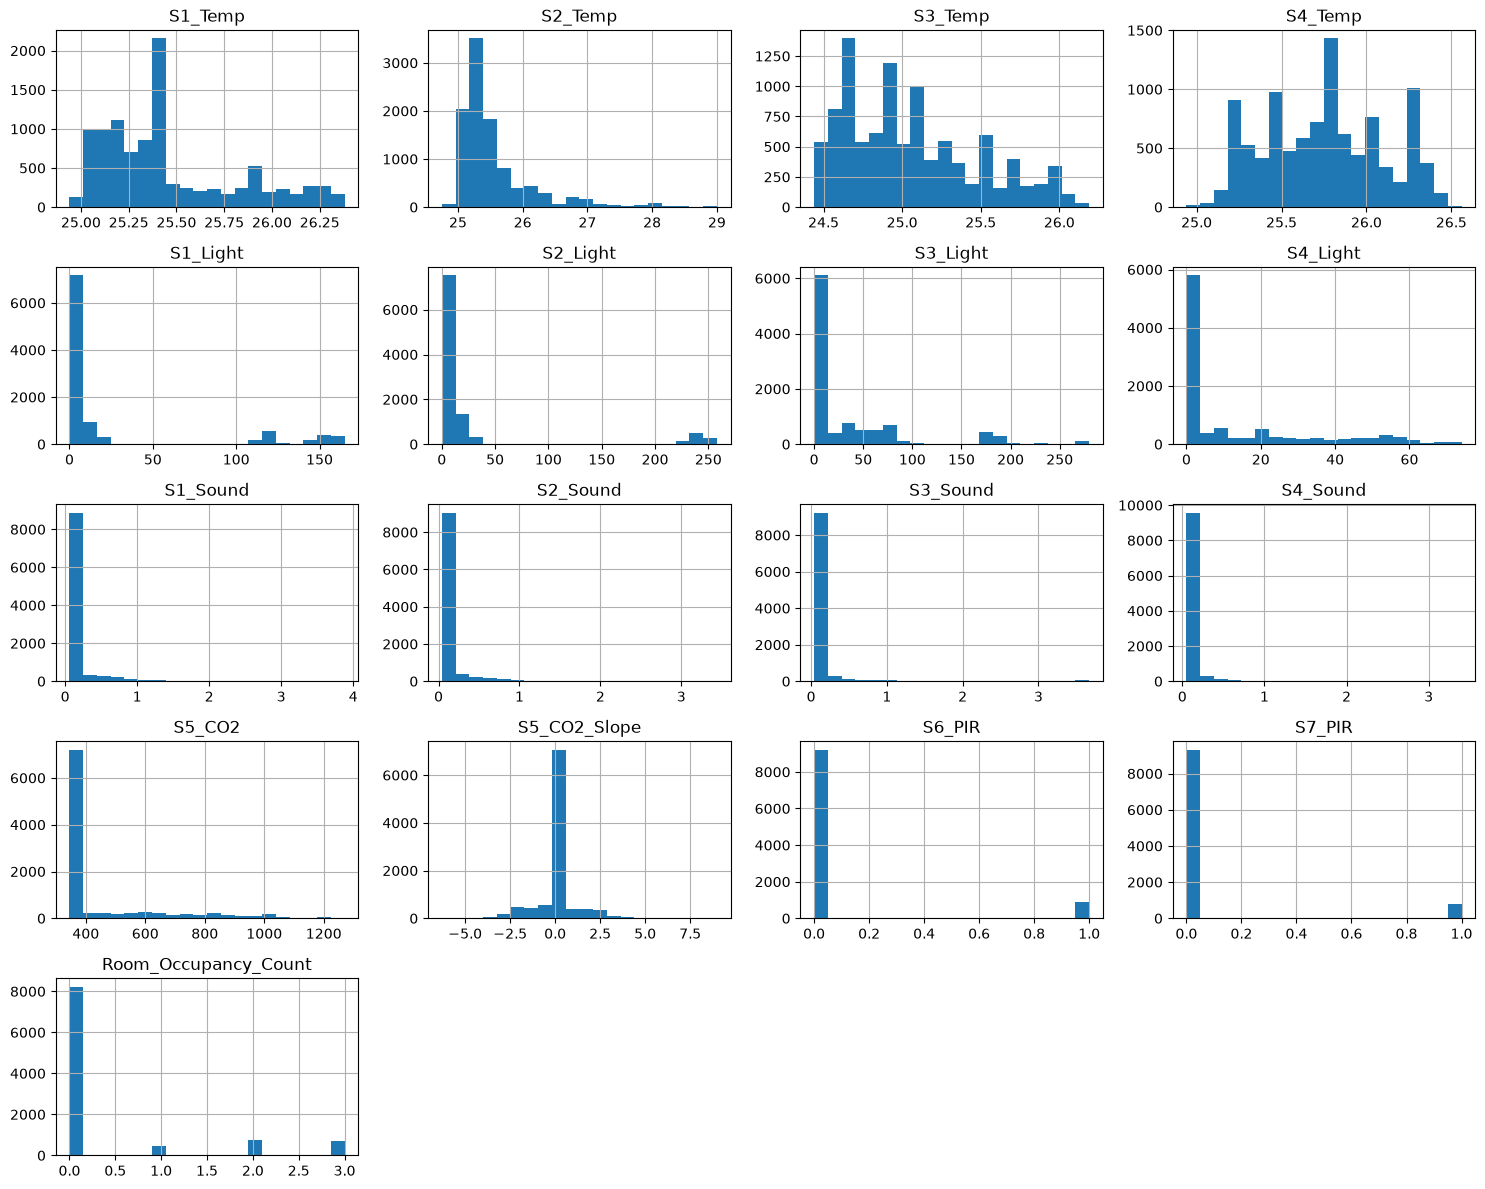

In [20]:
# 1 - Analyze the Distribution of Numerical Features
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14844\625609247.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns


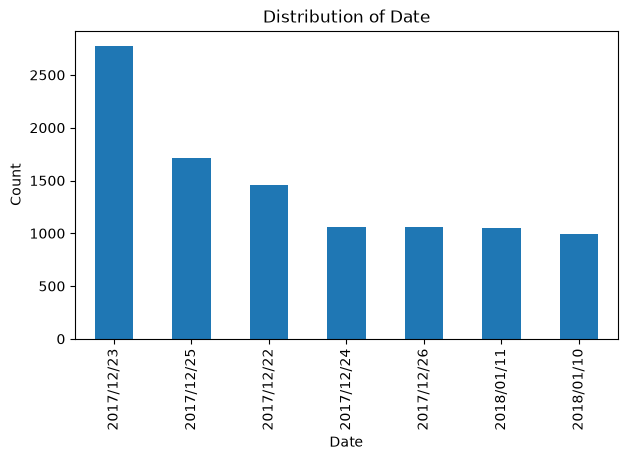

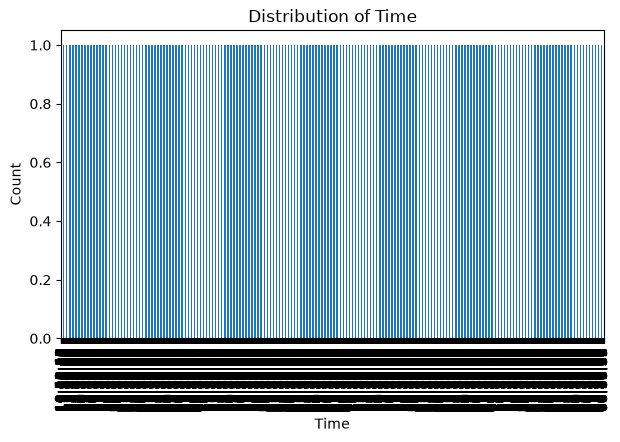

In [21]:
# 2 - Analyze the Distribution of Categorical Features
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    df[col].value_counts().plot(kind="bar", figsize=(7, 4))
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

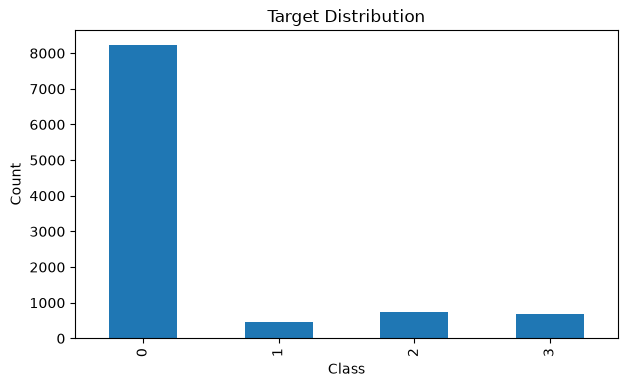

In [22]:
# 3 - Analyze the Target Variable
target = "Room_Occupancy_Count"

df[target].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

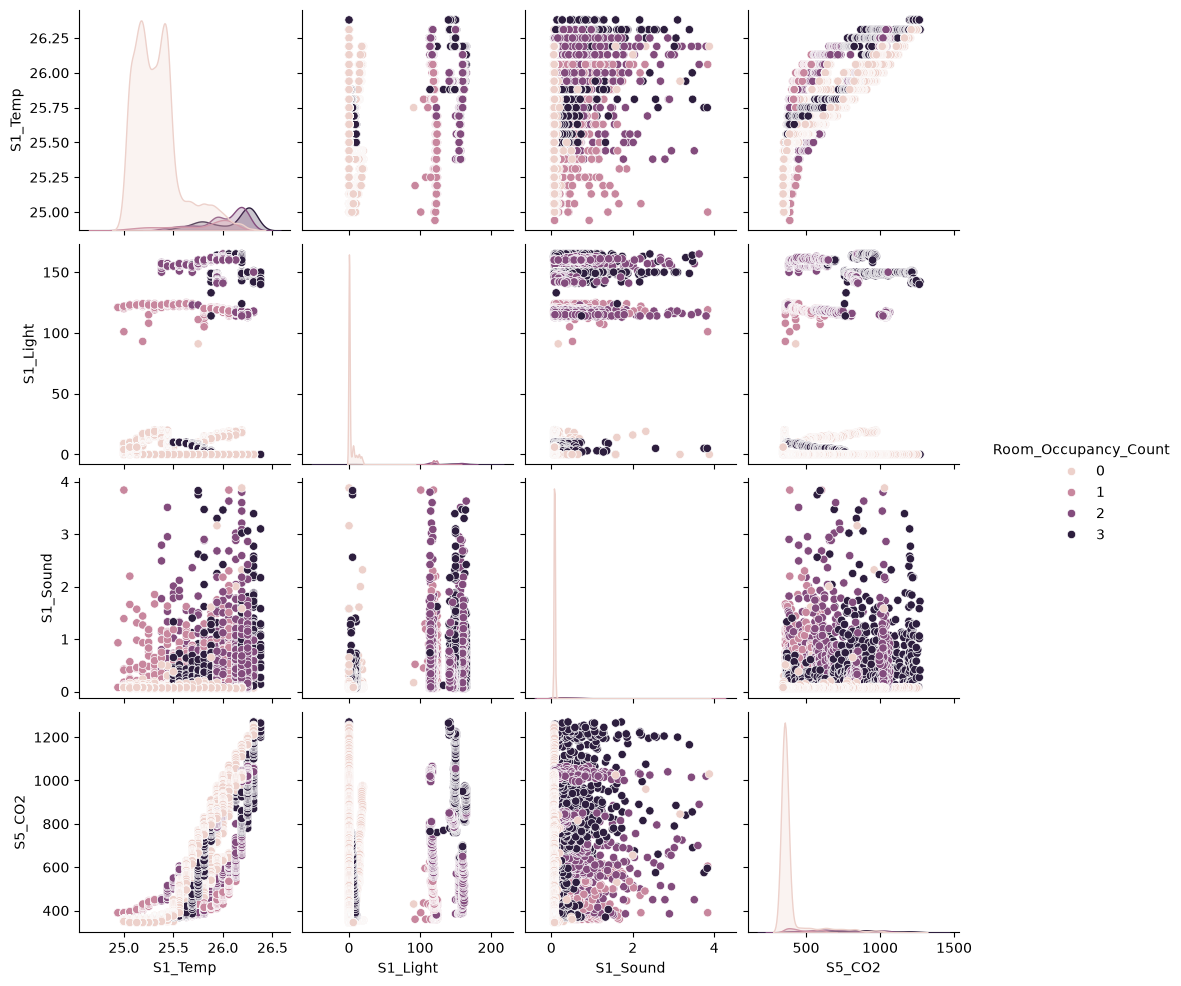

In [23]:
# 4. Analyze Relationships Between Numerical Features
selected_features = [
    "S1_Temp",
    "S1_Light",
    "S1_Sound",
    "S5_CO2",
    "Room_Occupancy_Count"
]

sns.pairplot(
    df[selected_features],
    hue="Room_Occupancy_Count"
)

plt.show()

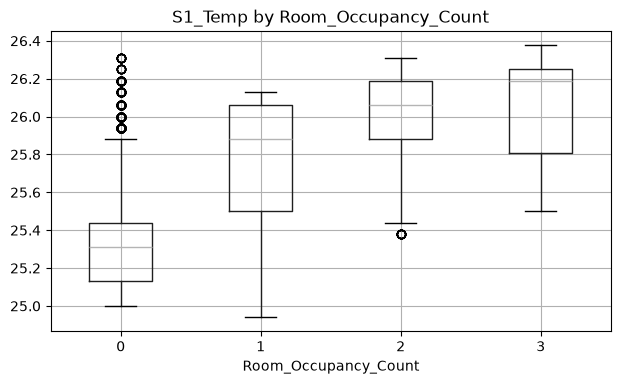

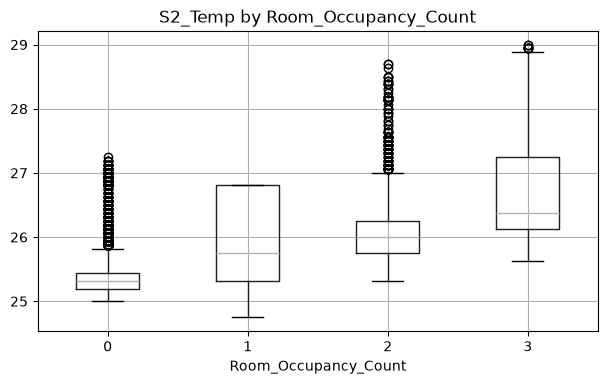

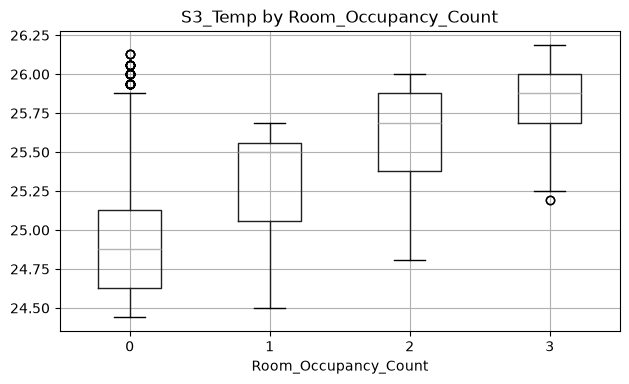

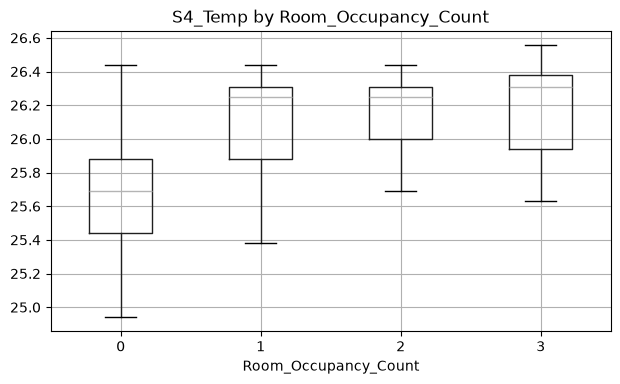

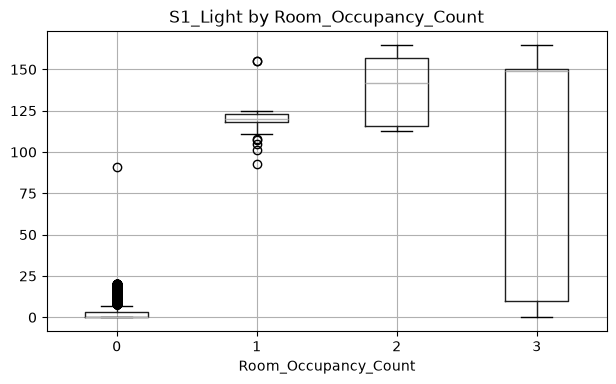

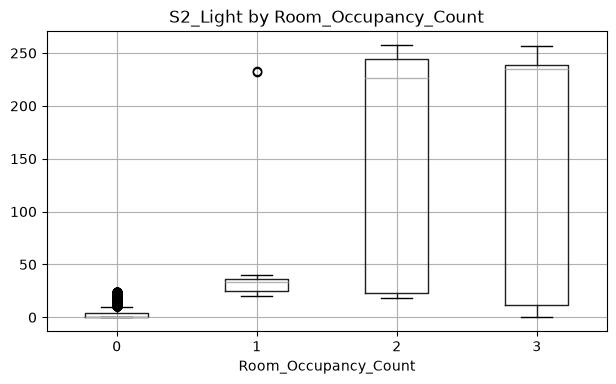

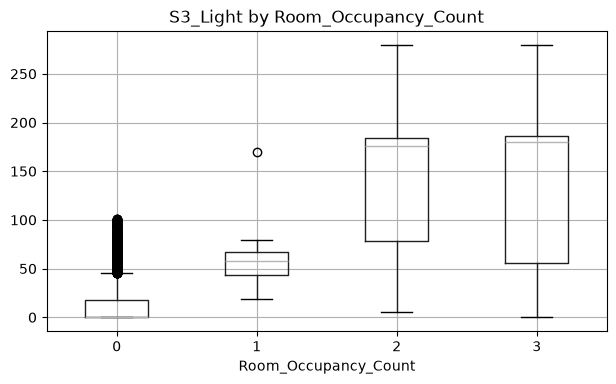

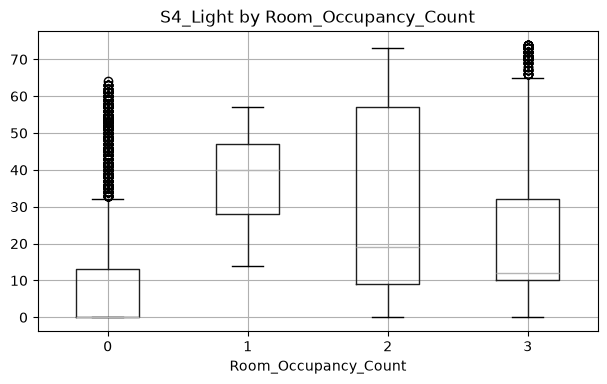

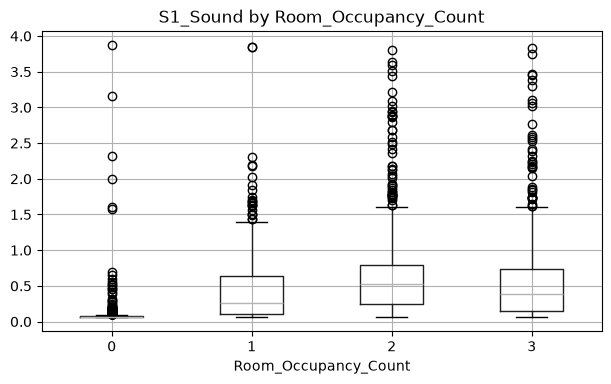

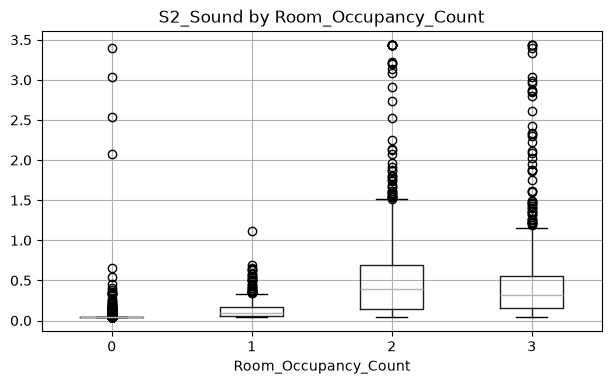

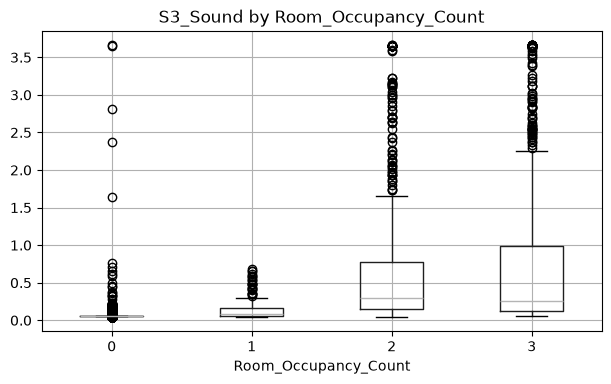

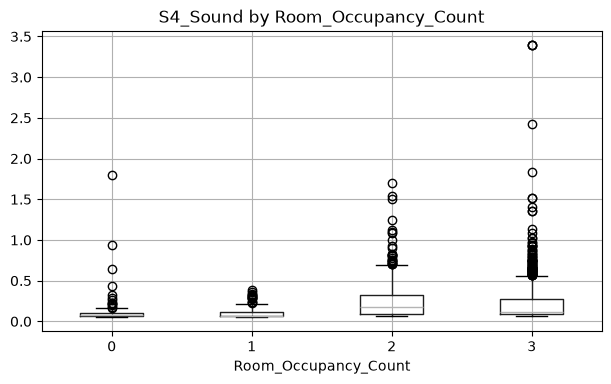

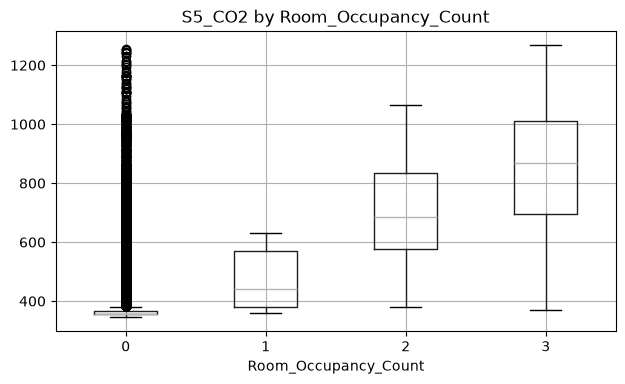

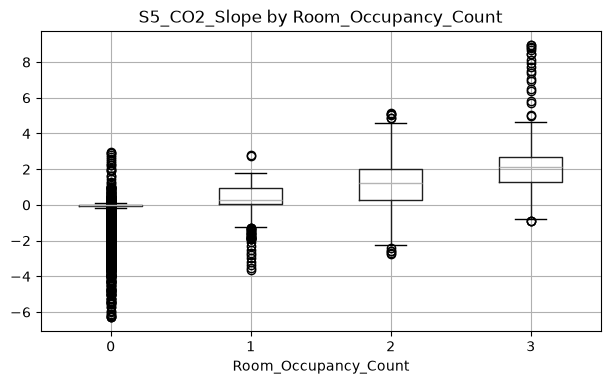

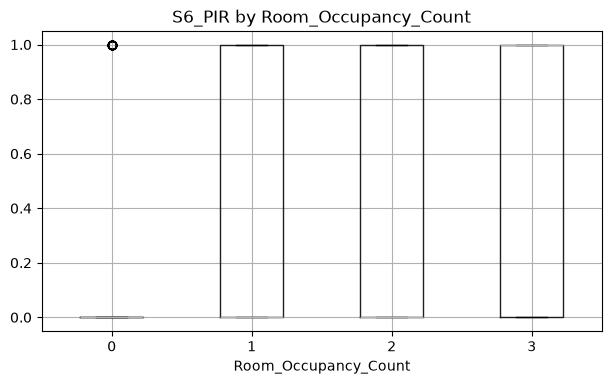

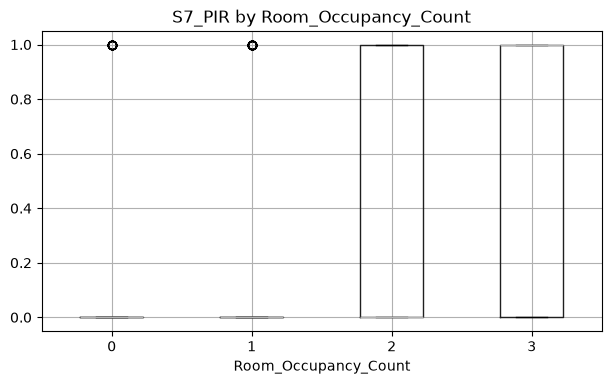

In [24]:
# 5. Analyze Numerical Features Against the Target
for col in numeric_cols:
    if col != target:
        df.boxplot(column=col, by=target, figsize=(7, 4))
        plt.title(f"{col} by {target}")
        plt.suptitle("")
        plt.show()

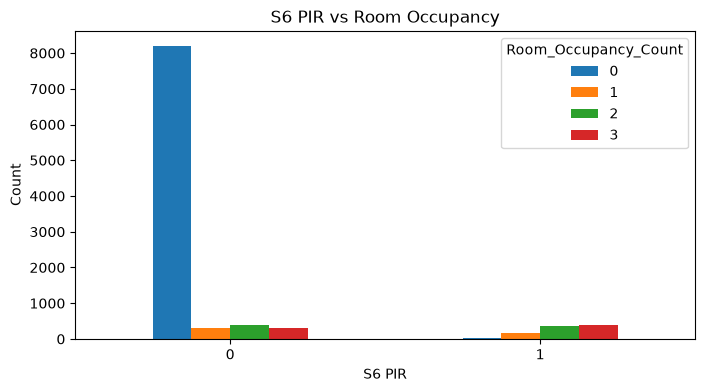

In [25]:
# 6. Analyze Categorical Features Against the Target
target = "Room_Occupancy_Count"

pd.crosstab(
    df["S6_PIR"],
    df[target]
).plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("S6 PIR vs Room Occupancy")
plt.xlabel("S6 PIR")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

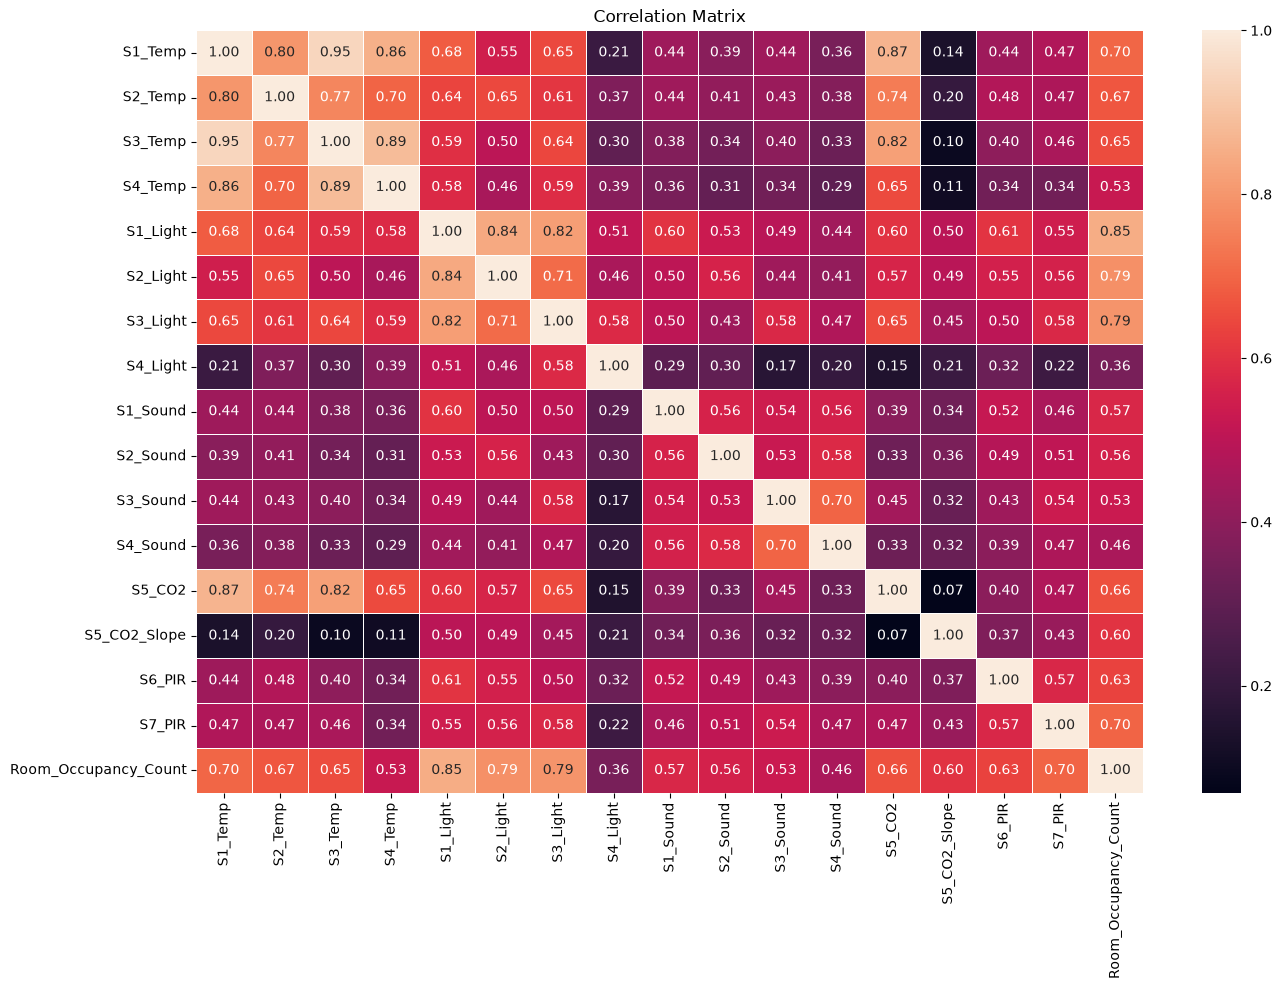

In [26]:
# 7. Analyze Correlations Between Numerical Features
# Calculate correlation matrix
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,      # Display correlation values
    fmt=".2f",       # Show two decimal places
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# **4) - Data Preprocessing**

#### **4.1 Encoding Categorical Variables** 
* LabelEncoder
* OneHotEncoder

![Room Occupancy Dataset](img5.png)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  10129 non-null  str           
 1   Time                  10129 non-null  str           
 2   S1_Temp               10129 non-null  float64       
 3   S2_Temp               10129 non-null  float64       
 4   S3_Temp               10129 non-null  float64       
 5   S4_Temp               10129 non-null  float64       
 6   S1_Light              10129 non-null  int64         
 7   S2_Light              10129 non-null  int64         
 8   S3_Light              10129 non-null  int64         
 9   S4_Light              10129 non-null  int64         
 10  S1_Sound              10129 non-null  float64       
 11  S2_Sound              10129 non-null  float64       
 12  S3_Sound              10129 non-null  float64       
 13  S4_Sound              10129

In [28]:
df.head(1)

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,Timestamp
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1,2017-12-22 10:49:41


In [29]:
df["Timestamp"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    errors="coerce"
)

df["Hour"] = df["Timestamp"].dt.hour
df["Minute"] = df["Timestamp"].dt.minute
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

df.drop(
    columns=["Date", "Time", "Timestamp"],
    inplace=True
)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   S1_Temp               10129 non-null  float64
 1   S2_Temp               10129 non-null  float64
 2   S3_Temp               10129 non-null  float64
 3   S4_Temp               10129 non-null  float64
 4   S1_Light              10129 non-null  int64  
 5   S2_Light              10129 non-null  int64  
 6   S3_Light              10129 non-null  int64  
 7   S4_Light              10129 non-null  int64  
 8   S1_Sound              10129 non-null  float64
 9   S2_Sound              10129 non-null  float64
 10  S3_Sound              10129 non-null  float64
 11  S4_Sound              10129 non-null  float64
 12  S5_CO2                10129 non-null  int64  
 13  S5_CO2_Slope          10129 non-null  float64
 14  S6_PIR                10129 non-null  int64  
 15  S7_PIR                10129 no

In [31]:
df.head(1)

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,Hour,Minute,DayOfWeek
0,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1,10,49,4


In [ ]:
# 4.2 - Train-Test Split
X = df.drop(columns=["Room_Occupancy_Count"])
y = df["Room_Occupancy_Count"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
# without stratify = y , the split is random and may not represent the original distribution of the target variable.

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

X_train shape: (8103, 19)
X_test shape: (2026, 19)

Training distribution:
Room_Occupancy_Count
0    81.229174
1     4.529187
2     7.392324
3     6.849315
Name: proportion, dtype: float64

Testing distribution:
Room_Occupancy_Count
0    81.243830
1     4.540967
2     7.354393
3     6.860809
Name: proportion, dtype: float64


In [36]:
# 3. Outlier Treatment
continuous_cols = [
    "S1_Temp",
    "S2_Temp",
    "S3_Temp",
    "S4_Temp",
    "S1_Light",
    "S2_Light",
    "S3_Light",
    "S4_Light",
    "S1_Sound",
    "S2_Sound",
    "S3_Sound",
    "S4_Sound",
    "S5_CO2",
    "S5_CO2_Slope"
]

X_train_capped = X_train.copy()
X_test_capped = X_test.copy()

for col in continuous_cols:

    # Calculate IQR from Training Data only
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap Training Data
    X_train_capped[col] = X_train[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    # Apply Training boundaries to Test Data
    X_test_capped[col] = X_test[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    

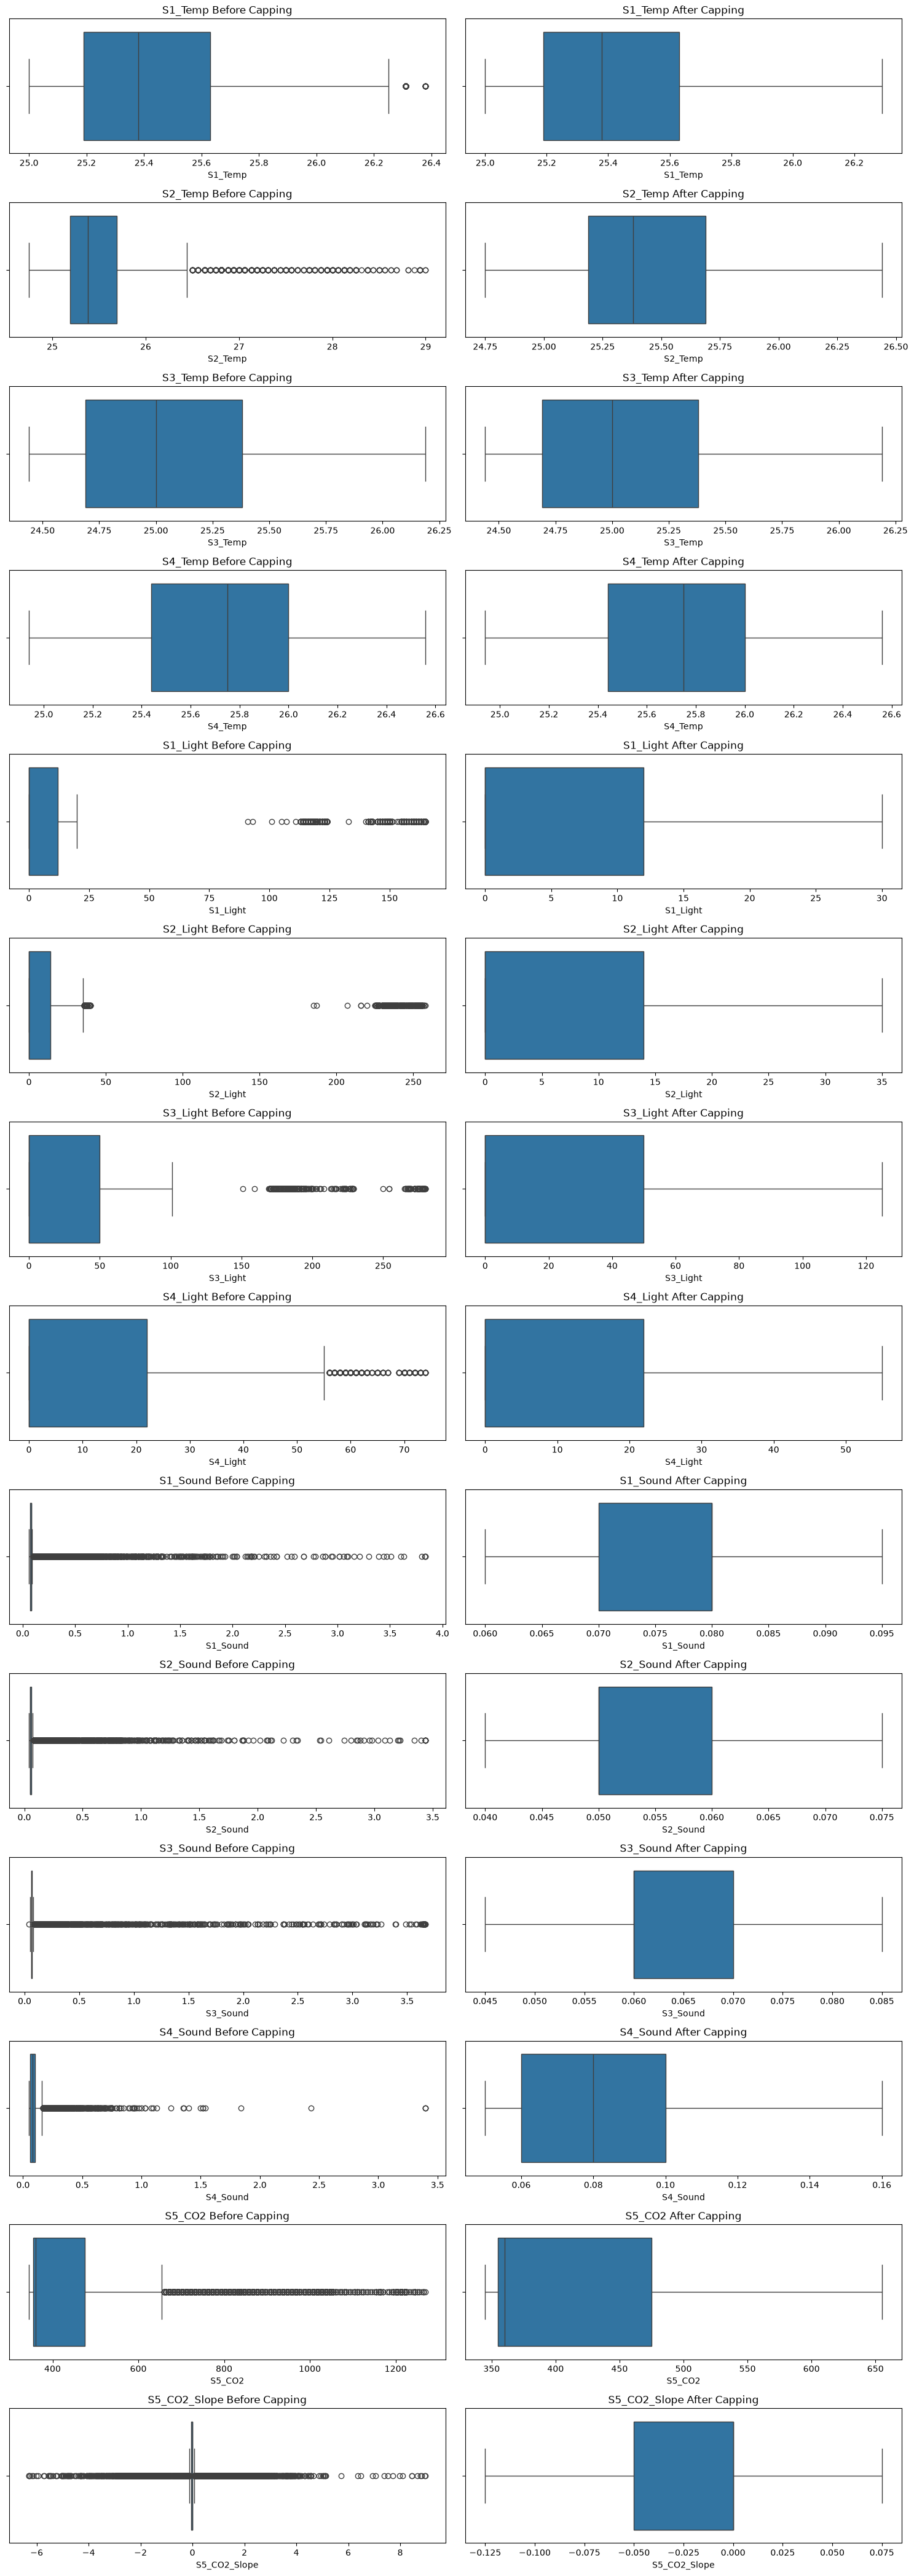

In [37]:
fig, axes = plt.subplots(
    nrows=len(continuous_cols),
    ncols=2,
    figsize=(15, len(continuous_cols) * 3)
)

for i, feature in enumerate(continuous_cols):

    # Before Capping
    sns.boxplot(
        x=X_train[feature],
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(
        f"{feature} Before Capping"
    )

    # After Capping
    sns.boxplot(
        x=X_train_capped[feature],
        ax=axes[i, 1]
    )

    axes[i, 1].set_title(
        f"{feature} After Capping"
    )

plt.tight_layout()
plt.show()

In [38]:
X_train_capped.head(1)

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Hour,Minute,DayOfWeek
8742,25.44,25.38,25.06,25.56,0,0,0,0,0.08,0.05,0.06,0.09,375,-0.125,0,0,21,5,2


In [39]:
# 4.4 Feature Scaling
scaler = StandardScaler()

# Learn scaling parameters from Training Data only
X_train_scaled = scaler.fit_transform(X_train_capped)

# Apply the same parameters to Test Data
X_test_scaled = scaler.transform(X_test_capped)

# Convert results back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_capped.columns,
    index=X_train_capped.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_capped.columns,
    index=X_test_capped.index
)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled.head(1)

X_train_scaled shape: (8103, 19)
X_test_scaled shape: (2026, 19)


,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Hour,Minute,DayOfWeek
8742,-0.043129,-0.269647,0.002226,-0.547871,-0.660982,-0.658705,-0.687192,-0.693538,0.240979,-0.377818,-0.412291,0.130062,-0.443513,-1.646809,-0.320311,-0.295072,1.307253,-1.410176,-0.580657


In [43]:
# Mean ≈ 0
# Standard Deviation ≈ 1
X_train_scaled.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
S1_Temp,8103.0,0.0,1.0,-1.30,-0.76,-0.21,0.50,2.38
S2_Temp,8103.0,0.0,1.0,-1.79,-0.73,-0.27,0.48,2.30
S3_Temp,8103.0,0.0,1.0,-1.45,-0.86,-0.14,0.75,2.64
S4_Temp,8103.0,0.0,1.0,-2.29,-0.88,-0.01,0.69,2.26
S1_Light,8103.0,0.0,1.0,-0.66,-0.66,-0.66,0.41,2.02
S2_Light,8103.0,0.0,1.0,-0.66,-0.66,-0.66,0.51,2.26
S3_Light,8103.0,-0.0,1.0,-0.69,-0.69,-0.69,0.55,2.39
S4_Light,8103.0,-0.0,1.0,-0.69,-0.69,-0.69,0.48,2.25
S1_Sound,8103.0,-0.0,1.0,-1.72,-0.74,0.24,0.24,1.71
S2_Sound,8103.0,-0.0,1.0,-1.30,-0.38,-0.38,0.54,1.92


In [ ]:
# 4.5 Handle Imbalanced Data
# ================================
# Install 
# !pip install imbalanced-learn

ModuleNotFoundError: No module named 'imblearn'

In [45]:
# 4.5 Handle Imbalanced Data
# ================================
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(
    random_state=42
)

X_train_balanced, y_train_balanced = oversampler.fit_resample(
    X_train_scaled,
    y_train
)

print("Before Balancing:")
print(y_train.value_counts().sort_index())

print("\nAfter Balancing:")
print(y_train_balanced.value_counts().sort_index())


Before Balancing:
Room_Occupancy_Count
0    6582
1     367
2     599
3     555
Name: count, dtype: int64

After Balancing:
Room_Occupancy_Count
0    6582
1    6582
2    6582
3    6582
Name: count, dtype: int64


In [46]:
print("Before Balancing:")
print("X_train:", X_train_scaled.shape)
print("y_train:", y_train.shape)

print("\nAfter Balancing:")
print("X_train_balanced:", X_train_balanced.shape)
print("y_train_balanced:", y_train_balanced.shape)

print("\nTest Data remains unchanged:")
print("X_test:", X_test_scaled.shape)
print("y_test:", y_test.shape)

Before Balancing:
X_train: (8103, 19)
y_train: (8103,)

After Balancing:
X_train_balanced: (26328, 19)
y_train_balanced: (26328,)

Test Data remains unchanged:
X_test: (2026, 19)
y_test: (2026,)


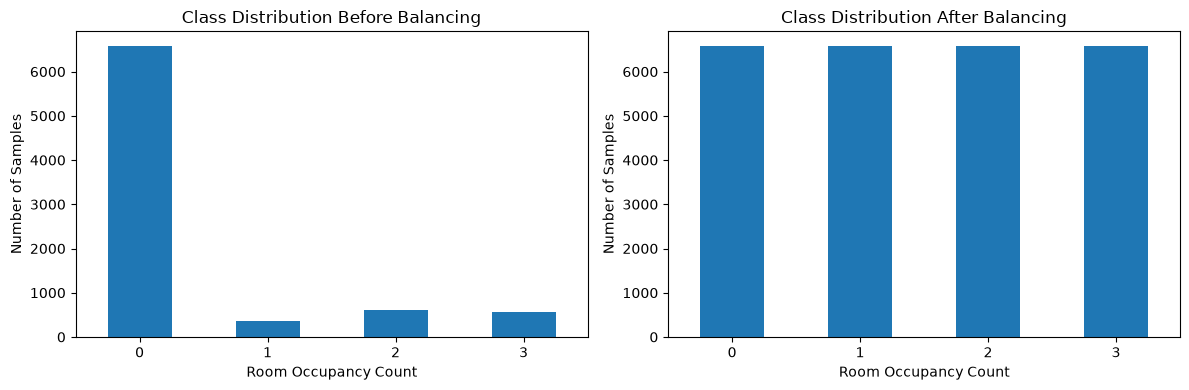

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_train.value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Class Distribution Before Balancing")
axes[0].set_xlabel("Room Occupancy Count")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=0)

y_train_balanced.value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Class Distribution After Balancing")
axes[1].set_xlabel("Room Occupancy Count")
axes[1].set_ylabel("Number of Samples")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# **5) - Build and Train Models**
* Cross Validation Setup

* Naive Bayes Pipeline → Naive Bayes Training and Tuning  → Naive Bayes Evaluation

* KNN Pipeline → KNN Training and Tuning → KNN Evaluation

* Decision Tree Pipeline → Decision Tree Training and Tuning → Decision Tree Evaluation

* Comparison Table
* Comparison Chart
* Best Model
* Best Hyperparameters

In [51]:
# Cross Validation Configuration

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Dictionary for storing final model results
model_results = {}

print("Training data:", X_train_capped.shape)
print("Testing data:", X_test_capped.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

Training data: (8103, 19)
Testing data: (2026, 19)

Training target distribution:
Room_Occupancy_Count
0    6582
1     367
2     599
3     555
Name: count, dtype: int64


In [52]:
# Naive Bayes Pipeline Construction

nb_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "oversampler",
            RandomOverSampler(random_state=42)
        ),
        (
            "model",
            GaussianNB()
        )
    ]
)

nb_pipeline

,steps,"[('scaler', ...), ('oversampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,random_state,42
,sampling_strategy,'auto'
,shrinkage,None
,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [53]:
# Naive Bayes Hyperparameter Tuning

nb_param_grid = {
    "model__var_smoothing": [
        1e-12,
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7,
        1e-6
    ]
}

nb_grid_search = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

nb_grid_search.fit(
    X_train_capped,
    y_train
)

best_nb_model = nb_grid_search.best_estimator_

print("Best Naive Bayes Parameters:")
print(nb_grid_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(round(nb_grid_search.best_score_, 4))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Naive Bayes Parameters:
{'model__var_smoothing': 1e-12}

Best Cross-Validation Macro F1:
0.7161


Naive Bayes Evaluation
----------------------------------------
Accuracy: 0.9274
Balanced Accuracy: 0.7536
Macro F1-score: 0.7191
Weighted F1-score: 0.9208
Macro ROC-AUC: 0.9862

Classification Report:

              precision    recall  f1-score   support

           0     0.9988    0.9915    0.9951      1646
           1     0.8155    0.9130    0.8615        92
           2     0.5372    0.8725    0.6650       149
           3     0.7021    0.2374    0.3548       139

    accuracy                         0.9274      2026
   macro avg     0.7634    0.7536    0.7191      2026
weighted avg     0.9362    0.9274    0.9208      2026



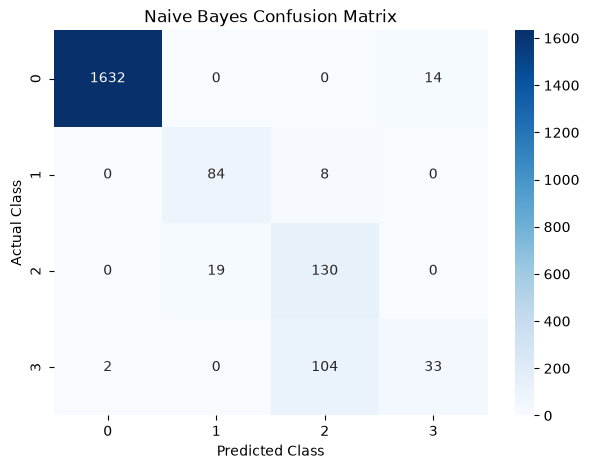

In [54]:
# Naive Bayes Evaluation

nb_predictions = best_nb_model.predict(
    X_test_capped
)

nb_probabilities = best_nb_model.predict_proba(
    X_test_capped
)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_balanced_accuracy = balanced_accuracy_score(
    y_test,
    nb_predictions
)

nb_macro_f1 = f1_score(
    y_test,
    nb_predictions,
    average="macro"
)

nb_weighted_f1 = f1_score(
    y_test,
    nb_predictions,
    average="weighted"
)

nb_roc_auc = roc_auc_score(
    y_test,
    nb_probabilities,
    multi_class="ovr",
    average="macro"
)

print("Naive Bayes Evaluation")
print("-" * 40)

print("Accuracy:", round(nb_accuracy, 4))
print("Balanced Accuracy:", round(nb_balanced_accuracy, 4))
print("Macro F1-score:", round(nb_macro_f1, 4))
print("Weighted F1-score:", round(nb_weighted_f1, 4))
print("Macro ROC-AUC:", round(nb_roc_auc, 4))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        nb_predictions,
        digits=4
    )
)

nb_confusion_matrix = confusion_matrix(
    y_test,
    nb_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    nb_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

model_results["Naive Bayes"] = {
    "Accuracy": nb_accuracy,
    "Balanced Accuracy": nb_balanced_accuracy,
    "Macro F1": nb_macro_f1,
    "Weighted F1": nb_weighted_f1,
    "ROC-AUC": nb_roc_auc,
    "Best CV Macro F1": nb_grid_search.best_score_
}

In [55]:
# KNN Pipeline Construction

knn_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "oversampler",
            RandomOverSampler(random_state=42)
        ),
        (
            "model",
            KNeighborsClassifier()
        )
    ]
)

knn_pipeline

,steps,"[('scaler', ...), ('oversampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,random_state,42
,sampling_strategy,'auto'
,shrinkage,None
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5


In [56]:
# KNN Hyperparameter Tuning

knn_param_grid = {
    "model__n_neighbors": [
        3,
        5,
        7,
        9,
        11,
        15
    ],
    
    "model__weights": [
        "uniform",
        "distance"
    ],
    
    "model__metric": [
        "euclidean",
        "manhattan"
    ]
}

knn_grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

knn_grid_search.fit(
    X_train_capped,
    y_train
)

best_knn_model = knn_grid_search.best_estimator_

print("Best KNN Parameters:")
print(knn_grid_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(round(knn_grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best KNN Parameters:
{'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'uniform'}

Best Cross-Validation Macro F1:
0.9774


KNN Evaluation
----------------------------------------
Accuracy: 0.9965
Balanced Accuracy: 0.9884
Macro F1-score: 0.9882
Weighted F1-score: 0.9966
Macro ROC-AUC: 0.9948

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    0.9994    0.9997      1646
           1     1.0000    0.9891    0.9945        92
           2     0.9671    0.9866    0.9767       149
           3     0.9855    0.9784    0.9819       139

    accuracy                         0.9965      2026
   macro avg     0.9882    0.9884    0.9882      2026
weighted avg     0.9966    0.9965    0.9966      2026



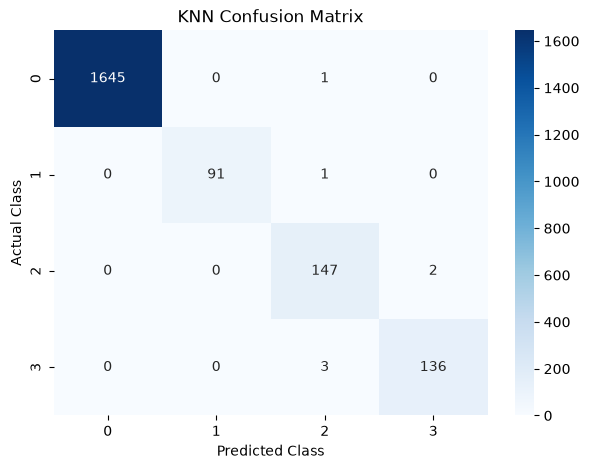

In [58]:
# KNN Evaluation

knn_predictions = best_knn_model.predict(
    X_test_capped
)

knn_probabilities = best_knn_model.predict_proba(
    X_test_capped
)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

knn_balanced_accuracy = balanced_accuracy_score(
    y_test,
    knn_predictions
)

knn_macro_f1 = f1_score(
    y_test,
    knn_predictions,
    average="macro"
)

knn_weighted_f1 = f1_score(
    y_test,
    knn_predictions,
    average="weighted"
)

knn_roc_auc = roc_auc_score(
    y_test,
    knn_probabilities,
    multi_class="ovr",
    average="macro"
)

print("KNN Evaluation")
print("-" * 40)

print("Accuracy:", round(knn_accuracy, 4))
print("Balanced Accuracy:", round(knn_balanced_accuracy, 4))
print("Macro F1-score:", round(knn_macro_f1, 4))
print("Weighted F1-score:", round(knn_weighted_f1, 4))
print("Macro ROC-AUC:", round(knn_roc_auc, 4))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        knn_predictions,
        digits=4
    )
)

knn_confusion_matrix = confusion_matrix(
    y_test,
    knn_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    knn_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

model_results["KNN"] = {
    "Accuracy": knn_accuracy,
    "Balanced Accuracy": knn_balanced_accuracy,
    "Macro F1": knn_macro_f1,
    "Weighted F1": knn_weighted_f1,
    "ROC-AUC": knn_roc_auc,
    "Best CV Macro F1": knn_grid_search.best_score_
}

In [59]:
#  Decision Tree Pipeline Construction

dt_pipeline = Pipeline(
    steps=[
        (
            "oversampler",
            RandomOverSampler(random_state=42)
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

dt_pipeline

,steps,"[('oversampler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,random_state,42
,sampling_strategy,'auto'
,shrinkage,None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None


In [60]:
# Decision Tree Hyperparameter Tuning

dt_param_grid = {
    "model__criterion": [
        "gini",
        "entropy"
    ],
    
    "model__max_depth": [
        None,
        5,
        10,
        15,
        20
    ],
    
    "model__min_samples_split": [
        2,
        5,
        10
    ],
    
    "model__min_samples_leaf": [
        1,
        2,
        4
    ]
}

dt_grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

dt_grid_search.fit(
    X_train_capped,
    y_train
)

best_dt_model = dt_grid_search.best_estimator_

print("Best Decision Tree Parameters:")
print(dt_grid_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(round(dt_grid_search.best_score_, 4))

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Decision Tree Parameters:
{'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Best Cross-Validation Macro F1:
0.9872


Decision Tree Evaluation
----------------------------------------
Accuracy: 0.9965
Balanced Accuracy: 0.9867
Macro F1-score: 0.9884
Weighted F1-score: 0.9965
Macro ROC-AUC: 0.9933

Classification Report:

              precision    recall  f1-score   support

           0     0.9988    1.0000    0.9994      1646
           1     0.9891    0.9891    0.9891        92
           2     0.9800    0.9866    0.9833       149
           3     0.9926    0.9712    0.9818       139

    accuracy                         0.9965      2026
   macro avg     0.9901    0.9867    0.9884      2026
weighted avg     0.9965    0.9965    0.9965      2026



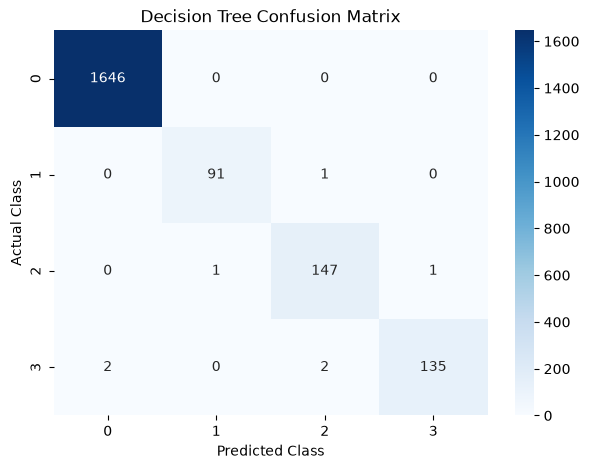

In [61]:
# Decision Tree Evaluation

dt_predictions = best_dt_model.predict(
    X_test_capped
)

dt_probabilities = best_dt_model.predict_proba(
    X_test_capped
)

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

dt_balanced_accuracy = balanced_accuracy_score(
    y_test,
    dt_predictions
)

dt_macro_f1 = f1_score(
    y_test,
    dt_predictions,
    average="macro"
)

dt_weighted_f1 = f1_score(
    y_test,
    dt_predictions,
    average="weighted"
)

dt_roc_auc = roc_auc_score(
    y_test,
    dt_probabilities,
    multi_class="ovr",
    average="macro"
)

print("Decision Tree Evaluation")
print("-" * 40)

print("Accuracy:", round(dt_accuracy, 4))
print("Balanced Accuracy:", round(dt_balanced_accuracy, 4))
print("Macro F1-score:", round(dt_macro_f1, 4))
print("Weighted F1-score:", round(dt_weighted_f1, 4))
print("Macro ROC-AUC:", round(dt_roc_auc, 4))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        dt_predictions,
        digits=4
    )
)

dt_confusion_matrix = confusion_matrix(
    y_test,
    dt_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    dt_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

model_results["Decision Tree"] = {
    "Accuracy": dt_accuracy,
    "Balanced Accuracy": dt_balanced_accuracy,
    "Macro F1": dt_macro_f1,
    "Weighted F1": dt_weighted_f1,
    "ROC-AUC": dt_roc_auc,
    "Best CV Macro F1": dt_grid_search.best_score_
}

In [ ]:
# Model Comparison Table [Macro F1]

comparison_df = pd.DataFrame(
    model_results
).T

comparison_df = comparison_df.sort_values(
    by="Macro F1",
    ascending=False
)

print("Models Comparison:")

display(
    comparison_df.round(4)
    )

Models Comparison:


,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,ROC-AUC,Best CV Macro F1
Decision Tree,0.9965,0.9867,0.9884,0.9965,0.9933,0.9872
KNN,0.9965,0.9884,0.9882,0.9966,0.9948,0.9774
Naive Bayes,0.9274,0.7536,0.7191,0.9208,0.9862,0.7161


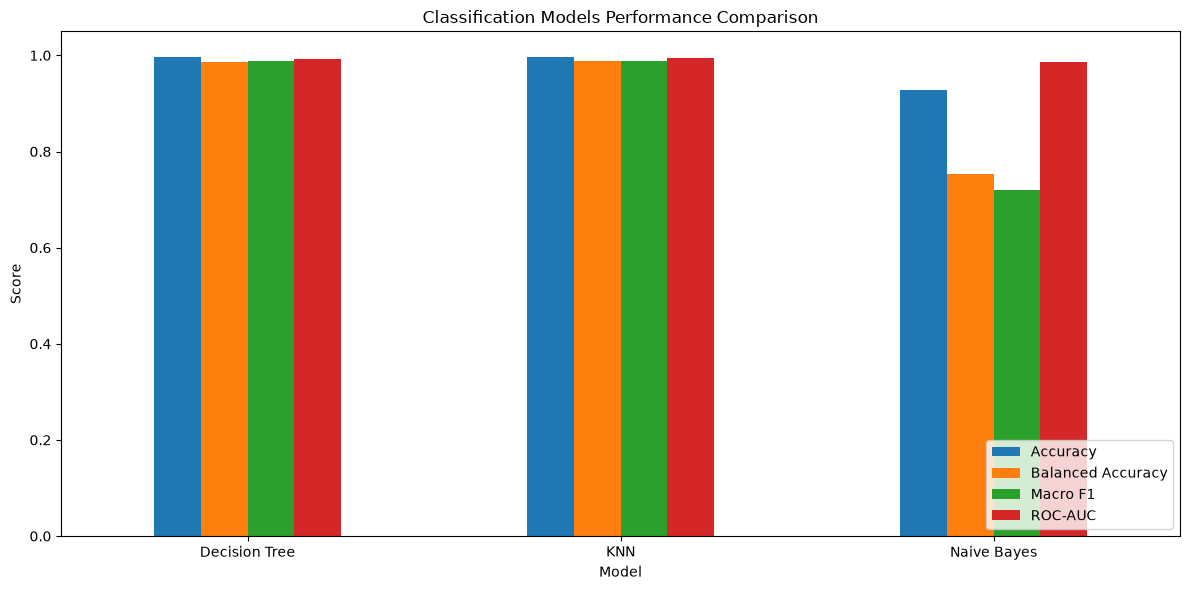

In [63]:
# Visual Model Comparison

comparison_df[
    [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Models Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [64]:
# Select Best Model

best_model_name = comparison_df[
    "Macro F1"
].idxmax()

best_model_score = comparison_df.loc[
    best_model_name,
    "Macro F1"
]

print("Best Model:", best_model_name)
print("Best Macro F1-score:", round(best_model_score, 4))

Best Model: Decision Tree
Best Macro F1-score: 0.9884


In [65]:
# Best Hyperparameters Summary

best_parameters = pd.DataFrame(
    {
        "Model": [
            "Naive Bayes",
            "KNN",
            "Decision Tree"
        ],
        
        "Best Parameters": [
            nb_grid_search.best_params_,
            knn_grid_search.best_params_,
            dt_grid_search.best_params_
        ]
    }
)

display(best_parameters)

,Model,Best Parameters
0,Naive Bayes,{'model__var_smoothing': 1e-12}
1,KNN,"{'model__metric': 'manhattan', 'model__n_neigh..."
2,Decision Tree,"{'model__criterion': 'gini', 'model__max_depth..."
